In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from IPython.display import display
from tabulate import tabulate
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score ,classification_report, confusion_matrix
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS, CountVectorizer
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from collections import Counter
import time
import warnings

## 1. Loading The Data
We start by loading the 20 newsgroups dataset's raw text data and insepct it to see what are we going to work with.

In [ ]:
# Load the data as is from the 20 newsgroups dataset.
train_data_raw = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)

Let's have a look at two randomly chosen example documents of the original raw data.

In [ ]:
# Save some example documents (chosen randomly, can change the index to see other documents).
example_document1 = train_data_raw.data[39]
example_document2 = train_data_raw.data[40]

print('1st Example:\n',example_document1)
print('2nd Example:\n',example_document2)

1st Example:
 From: bressler@iftccu.ca.boeing.com (Rick Bressler)
Subject: Re: Gun Lovers (was Re: My Gun is like my American Express Card)
Organization: Boeing Commercial Airplane Group
Lines: 104

/ iftccu:talk.politics.guns / vincent@cad.gatech.edu (Vincent Fox) / 10:34 am  Apr 14, 1993 /

This isn't rec.guns, so maybe this is getting a bet technical, but I
can't resist....

> - A revolver also has the advantage that if it misfires you just pull
>   the trigger again.

Sometimes.....  Depends on WHY it misfired....

> - A double-action revolver (almost all of them) can be hand-cocked first,
>   but will fire merely by pulling the trigger.

I can't imagine doing much combat type shooting single action.....

> - A misfire in a revolver merely means you must pull the trigger again
>   to rotate to the next round.

Assuming the cylinder WILL rotate....

> - A revolver can be carried with the 6th chamber empty and under the
>   hammer for maximum safety, but still can be drawn and fired 

By examining the examples of the original raw data, We noticed that headers, footers, and quoted text contain a lot of irrelevant information that could mislead the classifier or information. Headers often include metadata such as sender names, email addresses, and server details, which do not contribute to the actual topic of discussion. Footers usually contain signatures, which may introduce bias, and quoted text repeats parts of previous messages, creating redundancy. Keeping these elements could cause the model to overfit to superficial patterns rather than meaningful content. 
To ensure the classifier learns from the content of the document itself, we will use the remove parameter to exclude these elements when loading the training and test data.

In [4]:
categories = [
    'alt.atheism',
    'talk.religion.misc',
    'comp.graphics',
    'sci.space'
]

# Load the 20 Newsgroups dataset's training set with headers, footers, and quotes removed.
train_data = fetch_20newsgroups(subset='train', 
                                shuffle=True, 
                                random_state=42,
                                remove =("headers","footers","quotes"),
                               )

# Load the 20 Newsgroups dataset's testing set with headers, footers, and quotes removed.
test_data = fetch_20newsgroups(subset='test',
                               shuffle=True,
                               random_state=42,
                               remove=("headers","footers","quotes"),
                              )

# Get the raw documents and labels.
X_train, y_train = train_data.data, train_data.target
X_test, y_test = test_data.data, test_data.target

# Target names (class labels):
target_names = train_data.target_names
print('We can see that our 18,846 samples are divided as follows:')
print('Training data samples -',len(X_train))
print('Testing data samples -',len(X_test))
print('Number of classes -',len(target_names))

We can see that our 18,846 samples are divided as follows:
Training data samples - 11314
Testing data samples - 7532
Number of classes - 20


## 2. Data distribution
It's interesting to see how does the data is distributed to different classes, and how does the raw data looks like.

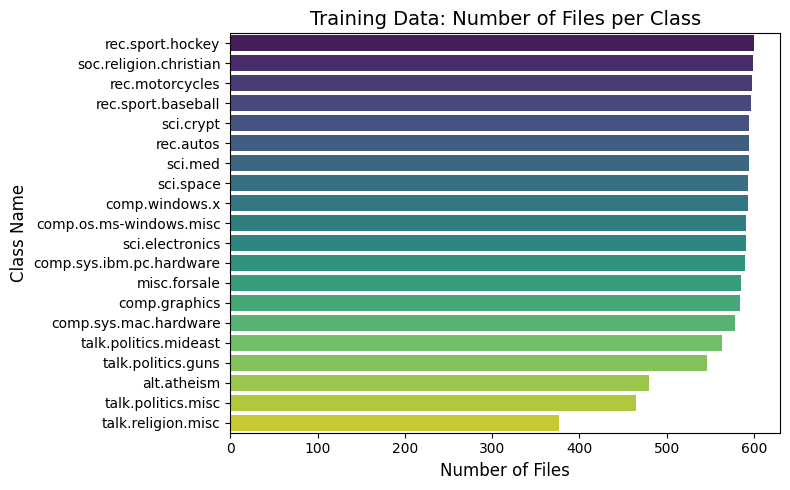

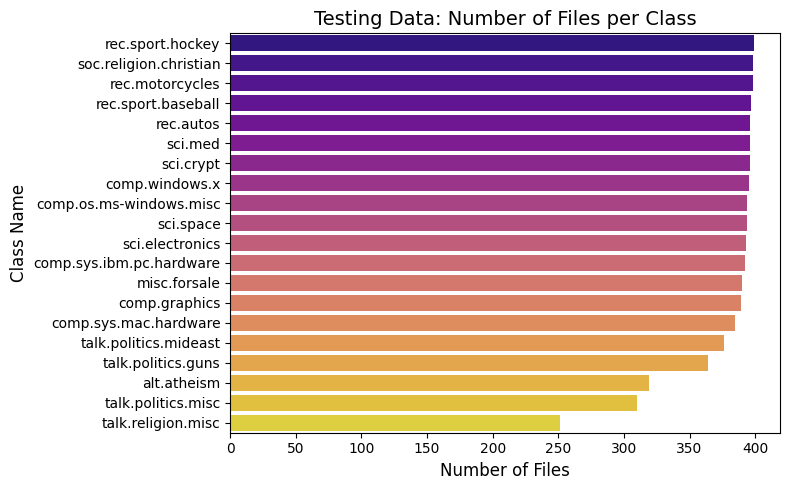

In [5]:
# Count the number of files in each class for the training data
train_class_counts = Counter(y_train)
test_class_counts = Counter(y_test)

# Create a bar plot to visualize the file counts per class
sorted_counts = sorted(train_class_counts.items(), key=lambda x: x[1], reverse=True)
classes = [target_names[idx] for idx, _ in sorted_counts]
counts = [count for _, count in sorted_counts]

sorted_counts_test = sorted(test_class_counts.items(), key=lambda x: x[1], reverse=True)
classes_test = [target_names[idx] for idx, _ in sorted_counts_test]
counts_test = [count for _, count in sorted_counts_test]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts, y=classes, hue=classes, palette="viridis", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Training Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout so that long class names fit
plt.show()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts_test, y=classes_test, hue=classes_test, palette="plasma", dodge=False)
plt.xlabel("Number of Files", fontsize=12)
plt.ylabel("Class Name", fontsize=12)
plt.title("Testing Data: Number of Files per Class", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()  # Adjust layout so that long class names fit
plt.show()

The data is quite balanced in the most part, However there are some classes("talk.religion.misc" (377 files), "talk.politics.misc" (465 files) and "alt.etheism" (480 files)) that have fewer files compared to the other classes which are around 600 files each. This might lead to higher accuracy on majority classes while underpreforming on minority classes when using Algorithms like Logistic Regression and SVM which optimize a global loss. same thing might happen with kNN and Decision Trees. 
We will see about that later in the project.

## 3. Preprocessing
We can see that our original raw data contains a lot of noise such as punctuation, numbers and special characters. 
As Tf-idf vectorizer will represent the data as a sparse matrix, if we wont remove the noise factors, they will add unnecessary dimensions that do not contribute to meaning and will increase computational cost without meaningful gains.
Also, extra noise can cause models to learn irrelevant patterns, making them less effective.
Another thing is that the data contains stop words(e.g., "the", "is", "and") which are common across all the data, meaning they do not help in distinguishing between categories so keeping them increase noise and will overshadow more meaningful words.

Concluding our wanted Preprocessing steps to execute:
1. Cleaning - Convert text to lowercase (treat "Apple" and "apple" as the same word) and remove punctuation, numbers and special characters.
4. Stopwords Removal - we will filter out common stopwords.
3. Tokenization - Using tf-idf vectorized we will convert the raw data into vectors.
5. Stemming - converting words to their base form, Changing Changed Change will turn into Chang.

In [6]:
def custom_analyzer(text):
    # 1. Cleaning & Lowercasing: Convert text to lowercase and remove non-word characters.
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    
    # 2. Tokenization: Tokenize the cleaned text.
    tokens = word_tokenize(text)
    # 3. Stopwords Removal: Filter out common English stopwords.
    tokens = [token for token in tokens if token not in ENGLISH_STOP_WORDS]
    
    # 4. Stemming: Convert tokens to their base form using PorterStemmer.
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    return stemmed_tokens

# Create a TF-IDF Vectorizer with the custom analyzer.
tfidf_vect = TfidfVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

count_vect = CountVectorizer(
    analyzer=custom_analyzer,  # use our custom analyzer function
    max_df=0.5,                # ignore terms that appear in more than 50% of the documents
    min_df=5,                   # ignore terms that appear in fewer than 5 documents
)

# Fit and transform the training data, then transform the testing data.
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)


# Fit and transform the training data, then transform the testing data.
X_train_tfidf = tfidf_vect.fit_transform(X_train) # fit - learn the vocabulary and idf, transform - converting documents into document-term matrix
X_test_tfidf = tfidf_vect.transform(X_test) # transform - converting documents into document-term matrix based on the vocabulary and idf learned from the training data



print("Count vectorized train data shape:", X_train_counts.shape)
print("Count vectorized test data shape:", X_test_counts.shape)
print("TF-IDF vectorized train data shape:", X_train_tfidf.shape)
print("TF-IDF vectorized test data shape:", X_test_tfidf.shape)

Count vectorized train data shape: (11314, 13171)
Count vectorized test data shape: (7532, 13171)
TF-IDF vectorized train data shape: (11314, 13171)
TF-IDF vectorized test data shape: (7532, 13171)


## 4. Train and Evaluate Multiple Classifiers
We want to see the performance of Logistic regression, Decision Tree, kNN, Naive Bayes and SVM on the data.
In order to do so we will wrap them all in a pipeline to run one by one in an organized way.

In [10]:
# Function to evaluate a classifier and return metrics
def evaluate_classifier(clf, X_train, X_test, y_train, y_test, clf_name):
    start_time = time.time()
    
    # Train the classifier
    clf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    
    training_time = time.time() - start_time
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)*100
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)*100
    recall = recall_score(y_test, y_pred, average='weighted')*100
    f1 = f1_score(y_test, y_pred, average='weighted')*100
    
    return {
        'Classifier': clf_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'y_pred': y_pred
    }


def format_results_table(df, groupby='n_components'):
    # Sort the results
    return df.sort_values(by=[groupby, 'Accuracy'], ascending=[True, False]).copy()


# Define the classifiers to test
classifiers = [
    ('Logistic Regression', LogisticRegression(random_state=42, max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('LinearSVC', LinearSVC(random_state=42, dual=False, max_iter=10000)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Naive Bayes', MultinomialNB())
]

# Store results for each classifier on the original data.
results_tfidf = []
results_count = []

# First, run the classifiers on the original TF-IDF data (no dimensionality reduction)
print(f"\n=== Running classifiers on original TF-IDF data ({X_train_tfidf.shape[1]} features) ===\n")
for clf_name, clf in classifiers:
    try:
        result = evaluate_classifier(clf, X_train_tfidf, X_test_tfidf, y_train, y_test, clf_name)
        result['Dimensions'] = 'Original (No Reduction)'
        result['n_components'] = X_train_tfidf.shape[1]
        results_tfidf.append(result)
        print(f"Completed: {clf_name} on original TF-IDF data")
    except Exception as e:
        print(f"Error with {clf_name} on original data: {e}")


# # First, run the classifiers on the original TF-IDF data (no dimensionality reduction)
# print(f"\n=== Running classifiers ===\n")
# for clf_name, clf in classifiers:
#     try:
#         result = evaluate_classifier(clf, X_train_counts, X_test_counts, y_train, y_test, clf_name)
#         result['Dimensions'] = 'Original (No Reduction)'
#         result['n_components'] = X_train_counts.shape[1]
#         results_count.append(result)
#         print(f"Completed: {clf_name}")
#     except Exception as e:
#         print(f"Error with {clf_name} on original data: {e}")


# Convert the results list to a DataFrame
results_df = pd.DataFrame(results_tfidf)
results_df_count = pd.DataFrame(results_count)

# Filter results for original dimensionality
original_results = results_df[results_df['Dimensions'] == 'Original (No Reduction)']
# original_results_count = results_df_count[results_df_count['Dimensions'] == 'Original (No Reduction)']

styled_df = format_results_table(original_results, groupby='n_components').style\
    .set_caption("Results for Original TF-IDF Data")\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

display(styled_df)

# styled_df2 = format_results_table(original_results_count, groupby='n_components').style\
#     .set_caption("Results for Original Count Vectorizer Data")\
#     .format({
#         'Accuracy': '{:.2f}%',
#         'Precision': '{:.2f}%',
#         'Recall': '{:.2f}%',
#         'F1-Score': '{:.2f}%'
#     })

# display(styled_df2)

# print(tabulate(format_results_table(original_results, groupby='n_components'), 
#                headers='keys', tablefmt='grid', showindex=False))


=== Running classifiers on original TF-IDF data (13171 features) ===

Completed: Logistic Regression on original TF-IDF data
Completed: Decision Tree on original TF-IDF data
Completed: Random Forest on original TF-IDF data
Completed: LinearSVC on original TF-IDF data
Completed: KNN on original TF-IDF data
Completed: Naive Bayes on original TF-IDF data


,Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),y_pred,Dimensions,n_components
0,Logistic Regression,68.37%,69.18%,68.37%,68.28%,3.910718,[ 7 5 19 ... 9 12 18],Original (No Reduction),13171
5,Naive Bayes,68.14%,72.40%,68.14%,66.83%,0.085039,[ 7 5 15 ... 9 3 15],Original (No Reduction),13171
3,LinearSVC,67.82%,68.24%,67.82%,67.76%,6.022353,[ 4 5 19 ... 9 12 18],Original (No Reduction),13171
2,Random Forest,61.02%,60.74%,61.02%,60.24%,103.608803,[ 4 5 19 ... 9 6 15],Original (No Reduction),13171
1,Decision Tree,43.80%,44.79%,43.80%,43.95%,16.256614,[ 4 0 19 ... 9 4 15],Original (No Reduction),13171
4,KNN,9.25%,11.70%,9.25%,8.81%,10.985715,[ 0 4 19 ... 1 0 1],Original (No Reduction),13171



=== Running classifiers on original TF-IDF data (13171 features) ===

Completed: Logistic Regression on original TF-IDF data


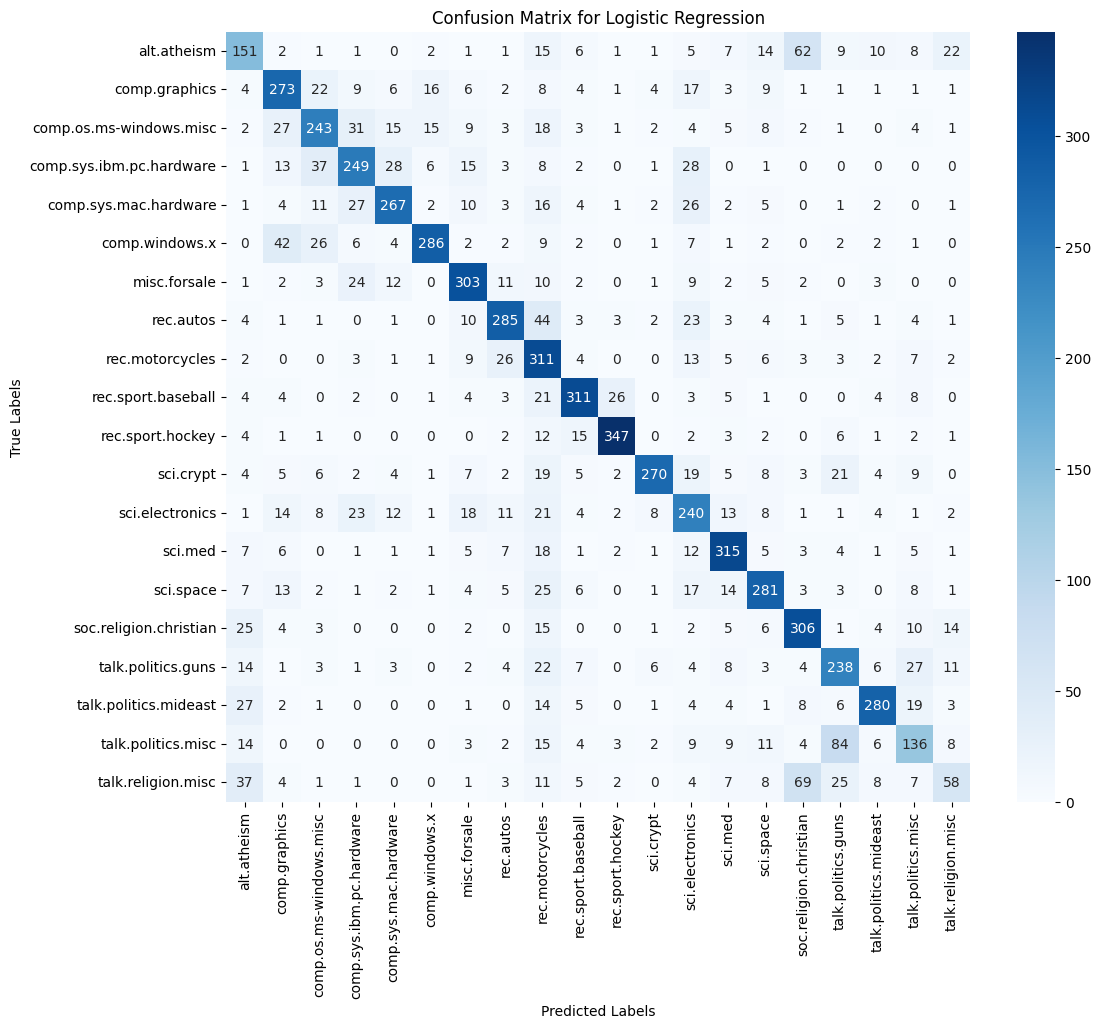

Completed: Decision Tree on original TF-IDF data


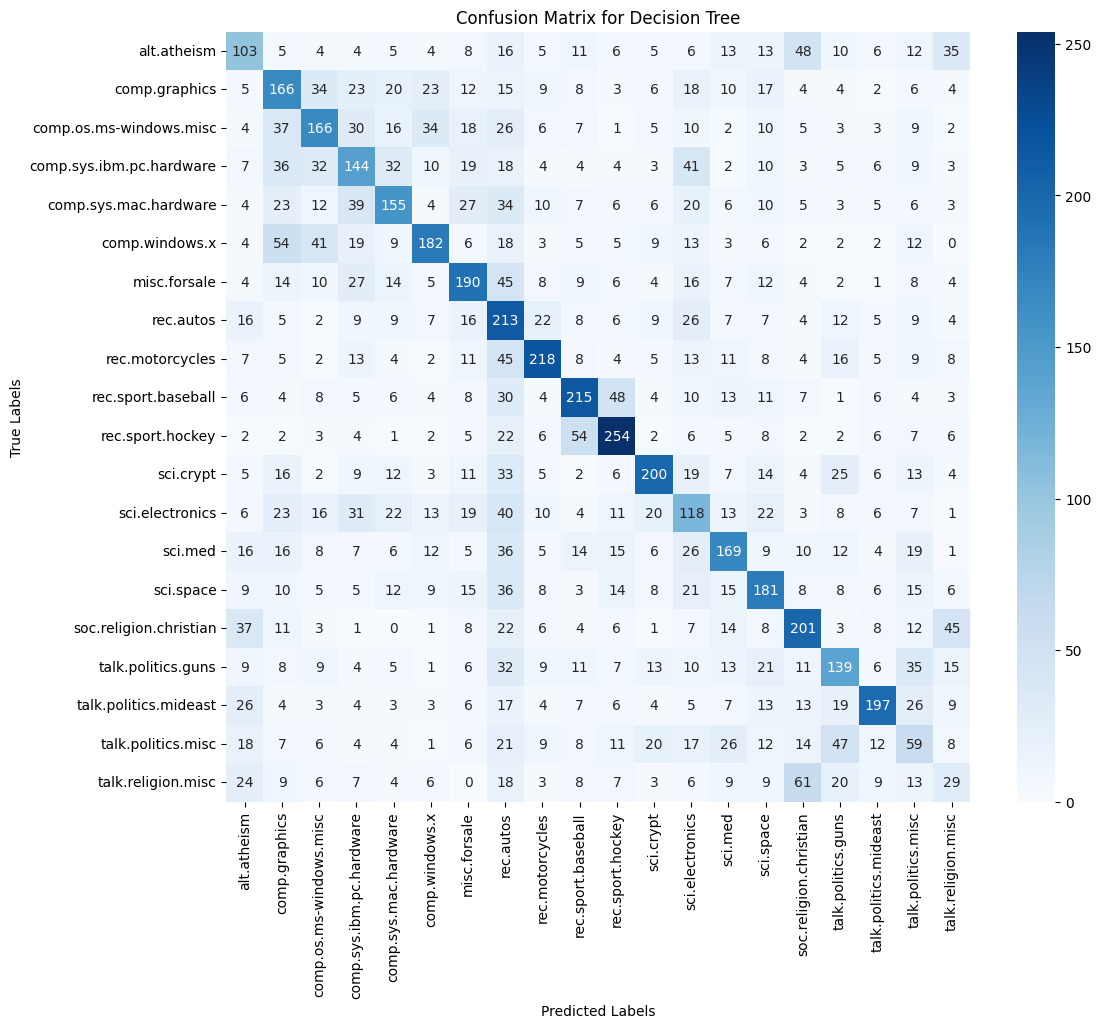

Completed: Random Forest on original TF-IDF data


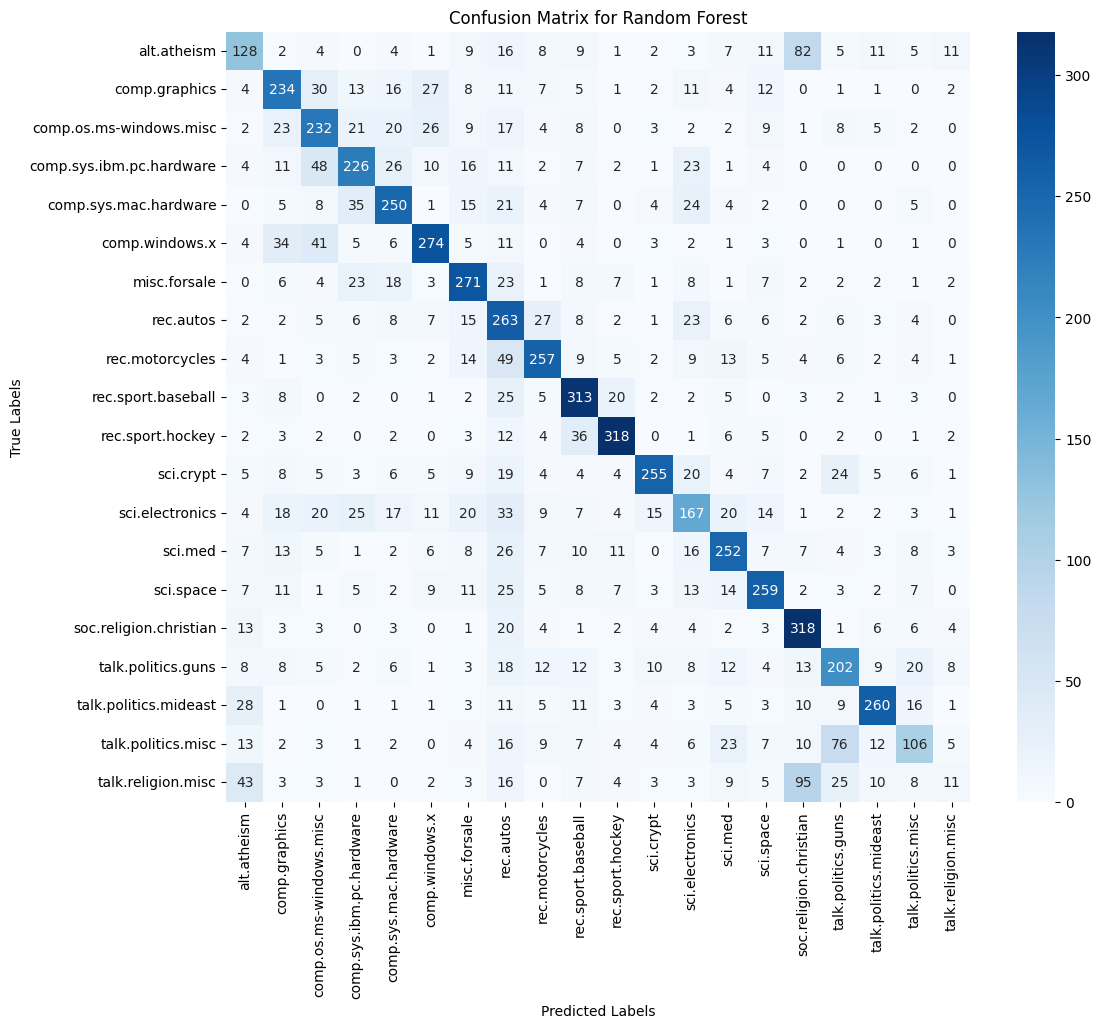

Completed: LinearSVC on original TF-IDF data


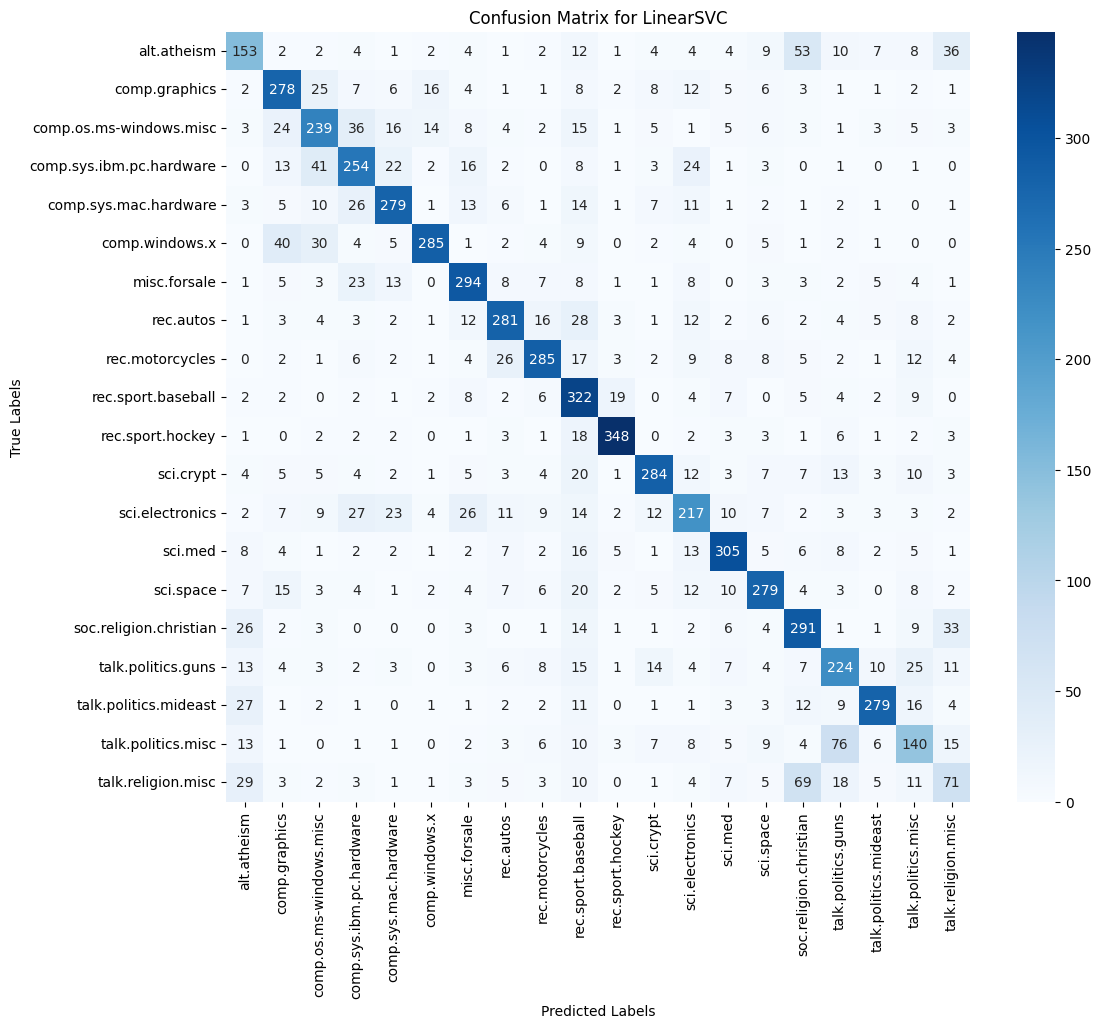

Completed: KNN on original TF-IDF data


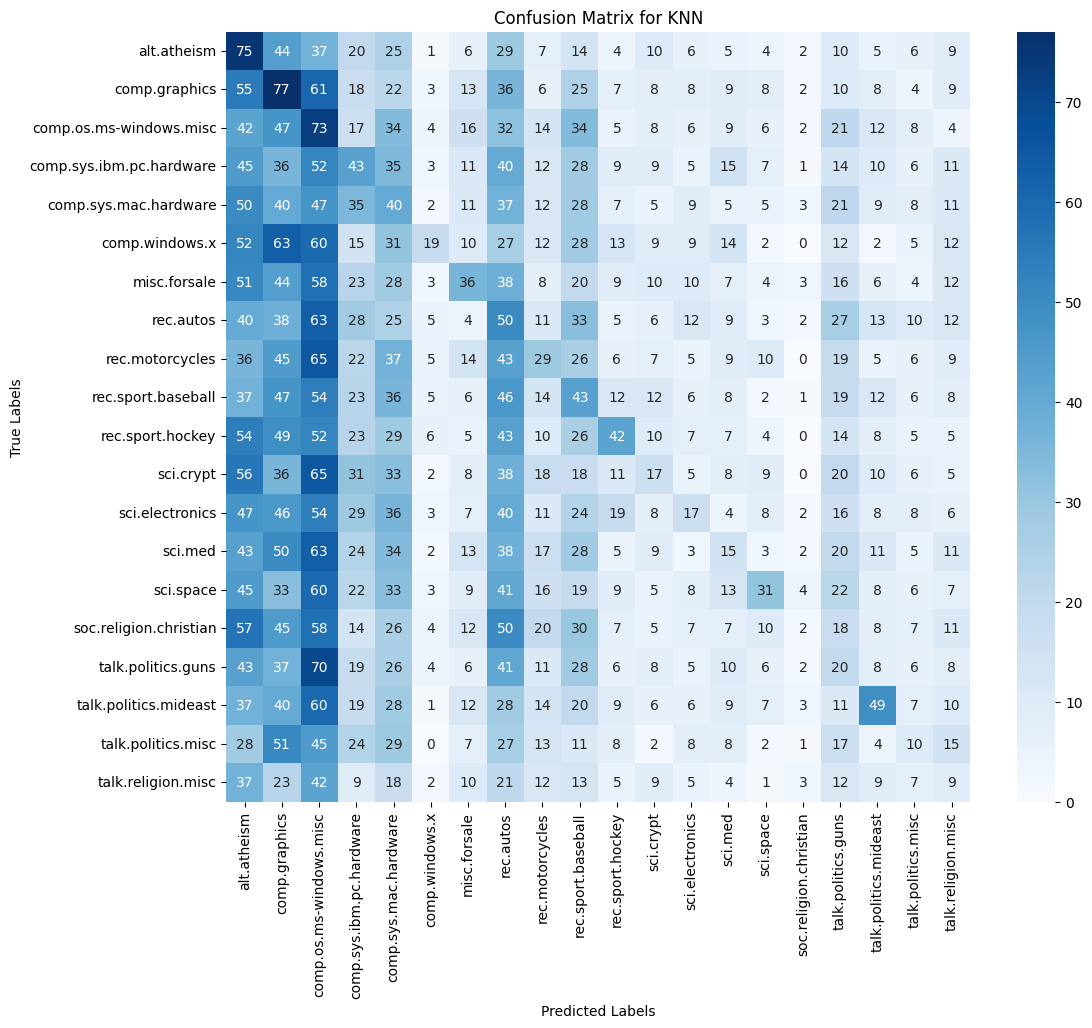

Completed: Naive Bayes on original TF-IDF data


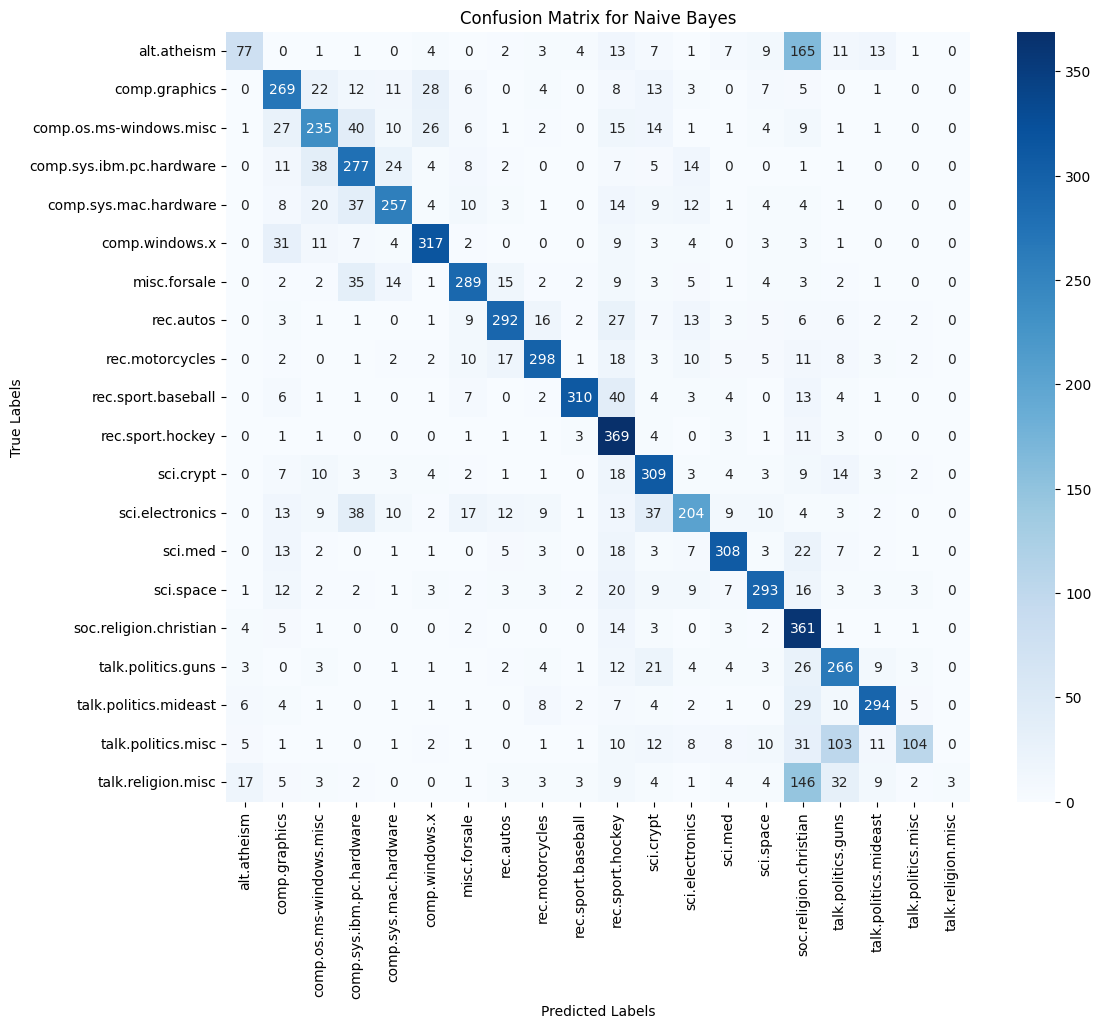

In [ ]:

# Store results for each classifier along with predictions
results_tfidf = []

print(f"\n=== Running classifiers on original TF-IDF data ({X_train_tfidf.shape[1]} features) ===\n")
for clf_name, clf in classifiers:
    try:
        result = evaluate_classifier(clf, X_train_tfidf, X_test_tfidf, y_train, y_test, clf_name)
        result['Dimensions'] = 'Original (No Reduction)'
        result['n_components'] = X_train_tfidf.shape[1]
        results_tfidf.append(result)

        print(f"Completed: {clf_name} on original TF-IDF data")

        # Plot confusion matrix
        cm = confusion_matrix(y_test, result['y_pred'])
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=train_data.target_names, yticklabels=train_data.target_names)
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'Confusion Matrix for {clf_name}')
        plt.show()

    except Exception as e:
        print(f"Error with {clf_name} on original data: {e}")


## 5. Dimensionality Reduction - High vs Low explained variance
As we know, our training data contains 13171 features(possible terms) in the sparse matrix. Most documents will contain only a small fraction of the possible terms, with most entries being zero.
We want to check if dimension reduction might help us getting rid of less important features that might add noise, prevent overfitting, prevent models from memorizing data patterns that don't generalize, etc. It seems quite logical to us that maintaining a reasonable amount of explained variance (70%) of the original data after the dimensionality reduction, will help us get better results with our classifiers than on low values of explained variance, but is that so ? 


Optimal n_components based on 70% explained variance: 1699


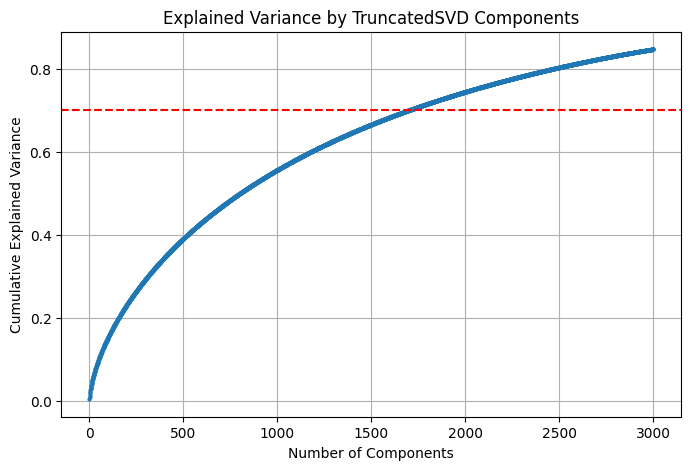

In [9]:
import numpy as np
# Define a custom transformer to shift the data to make it non-negative (might happen after dimensionality reduction)
# This is important for Naive Bayes and kNN classifiers
class ShiftTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Determine the shift value needed to make all values non-negative
        self.shift_ = -X.min() if X.min() < 0 else 0
        return self

    def transform(self, X, y=None):
        return X + self.shift_
    
# --- Optimal n_components Selection via Explained Variance Analysis ---
# Set a high number of components to analyze the explained variance
max_components = 3000
svd_full = TruncatedSVD(n_components=max_components, random_state=42)
svd_full.fit(X_train_tfidf)
cumulative_variance = np.cumsum(svd_full.explained_variance_ratio_)
# Set threshold for desired explained variance (e.g., 70%)
threshold = 0.70
optimal_n_components = np.argmax(cumulative_variance >= threshold) + 1  # +1 because index starts at 0

print(f"\nOptimal n_components based on {threshold*100:.0f}% explained variance: {optimal_n_components}")
# Optional: Plot the cumulative explained variance curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_components + 1), cumulative_variance, marker='o', markersize=2)
plt.axhline(y=threshold, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by TruncatedSVD Components')
plt.grid(True)
plt.show()



We get that the number of components required to get 70% explained variance is 1699.
So that will be that argument we will give the TruncatedSVD algorithm and after running it, we will check the performance of our
classifiers and see if they did better or worse.

In [10]:
# --- SVD Pipeline Testing with Optimal n_components and other values ---
svd_results = []

print(f"\n=== Running SVD with n_components={optimal_n_components} ===\n")

# Create SVD pipeline
svd_pipeline = make_pipeline(
    TruncatedSVD(n_components=optimal_n_components, random_state=42),
    ShiftTransformer(),          # Shift data to remove negatives
    Normalizer(copy=False)       # Normalizer is important for kNN and Naive Bayes
)

# Apply SVD transformation
X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
X_test_svd = svd_pipeline.transform(X_test_tfidf)

# Get explained variance ratio
svd = svd_pipeline.named_steps['truncatedsvd']
explained_variance = svd.explained_variance_ratio_.sum()
print(f"SVD with {optimal_n_components} components explains {explained_variance:.2%} of variance")
# Test each classifier on the reduced data
for clf_name, clf in classifiers:
    try:
        result = evaluate_classifier(clf, X_train_svd, X_test_svd, y_train, y_test, clf_name)
        result['Dimensions'] = 'SVD'
        result['n_components'] = optimal_n_components
        result['Explained Variance'] = explained_variance
        svd_results.append(result)
        print(f"Completed: {clf_name} with n_components={optimal_n_components}")
    except Exception as e:
        print(f"Error with {clf_name} on n_components={optimal_n_components}: {e}")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(svd_results)

# Filter results for SVD dimensionality reduction
svd_results = results_df[results_df['Dimensions'] == 'SVD']

# Display table for SVD reduced data results without row numbers
styled_df = format_results_table(svd_results, groupby='n_components').style\
    .set_caption("=== Results for SVD Reduced Data ===")\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

display(styled_df)


=== Running SVD with n_components=1699 ===

SVD with 1699 components explains 69.68% of variance
Completed: Logistic Regression with n_components=1699
Completed: Decision Tree with n_components=1699
Completed: Random Forest with n_components=1699
Completed: LinearSVC with n_components=1699
Completed: KNN with n_components=1699
Completed: Naive Bayes with n_components=1699


,Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Dimensions,n_components,Explained Variance
3,LinearSVC,64.09%,63.70%,64.09%,62.50%,31.626316,SVD,1699,0.696766
2,Random Forest,53.13%,52.67%,53.13%,52.28%,222.185761,SVD,1699,0.696766
0,Logistic Regression,50.48%,58.40%,50.48%,47.18%,2.929953,SVD,1699,0.696766
1,Decision Tree,36.56%,36.89%,36.56%,36.52%,125.903826,SVD,1699,0.696766
5,Naive Bayes,11.50%,22.94%,11.50%,6.68%,0.208162,SVD,1699,0.696766
4,KNN,10.44%,67.31%,10.44%,10.49%,5.115129,SVD,1699,0.696766


Let's see what we will get with lower values of explained variance.
We will run the TruncatedSVD with ```n_components``` values of ```150,350,500``` which gives explained variance values of 

In [ ]:
# --- SVD Pipeline Testing with Optimal n_components and other values ---
svd_results = []

n_components_list = [200,400,600]

# Run SVD with different n_components values
for n_components in n_components_list:
    print(f"\n=== Running SVD with n_components={n_components} ===\n")
    
    # Create SVD pipeline
    svd_pipeline = make_pipeline(
        TruncatedSVD(n_components=n_components, random_state=42),
        Normalizer(copy=False)
    )
    
    # Apply SVD transformation
    X_train_svd = svd_pipeline.fit_transform(X_train_tfidf)
    X_test_svd = svd_pipeline.transform(X_test_tfidf)
    
    # Get explained variance ratio
    svd = svd_pipeline.named_steps['truncatedsvd']
    explained_variance = svd.explained_variance_ratio_.sum()
    print(f"SVD with {n_components} components explains {explained_variance:.2%} of variance")
    
    # Test each classifier on the reduced data
    for clf_name, clf in classifiers:
        try:
            result = evaluate_classifier(clf, X_train_svd, X_test_svd, y_train, y_test, clf_name)
            result['Dimensions'] = 'SVD'
            result['n_components'] = n_components
            result['Explained Variance'] = explained_variance
            svd_results.append(result)
            print(f"Completed: {clf_name} with n_components={n_components}")
        except Exception as e:
            print(f"Error with {clf_name} on n_components={n_components}: {e}")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(svd_results)

# Filter results for SVD dimensionality reduction
svd_results = results_df[results_df['Dimensions'] == 'SVD'] 

# Display table for SVD reduced data results without row numbers
styled_df = format_results_table(svd_results, groupby='n_components').style\
    .set_caption("=== Results for SVD Reduced Data ===")\
    .format({
        'Accuracy': '{:.2f}%',
        'Precision': '{:.2f}%',
        'Recall': '{:.2f}%',
        'F1-Score': '{:.2f}%'
    })

display(styled_df)



=== Running SVD with n_components=200 ===

SVD with 200 components explains 22.87% of variance
Completed: Logistic Regression with n_components=200
Completed: Decision Tree with n_components=200
Completed: Random Forest with n_components=200
Completed: LinearSVC with n_components=200
Completed: KNN with n_components=200
Error with Naive Bayes on n_components=200: Negative values in data passed to MultinomialNB (input X).

=== Running SVD with n_components=400 ===

SVD with 400 components explains 34.17% of variance
Completed: Logistic Regression with n_components=400
Completed: Decision Tree with n_components=400
Completed: Random Forest with n_components=400
Completed: LinearSVC with n_components=400
Completed: KNN with n_components=400
Error with Naive Bayes on n_components=400: Negative values in data passed to MultinomialNB (input X).

=== Running SVD with n_components=600 ===

SVD with 600 components explains 42.67% of variance
Completed: Logistic Regression with n_components=600

,Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Dimensions,n_components,Explained Variance
3,LinearSVC,63.32%,63.09%,63.32%,62.69%,7.026573,SVD,200,0.228730
0,Logistic Regression,63.04%,63.64%,63.04%,62.88%,6.012430,SVD,200,0.228730
2,Random Forest,57.24%,57.16%,57.24%,56.66%,56.964987,SVD,200,0.228730
4,KNN,43.96%,53.73%,43.96%,46.35%,0.741069,SVD,200,0.228730
1,Decision Tree,38.02%,38.39%,38.02%,38.08%,13.131629,SVD,200,0.228730
5,Logistic Regression,65.36%,65.92%,65.36%,65.25%,3.207073,SVD,400,0.341735
8,LinearSVC,65.32%,65.37%,65.32%,64.97%,14.983337,SVD,400,0.341735
7,Random Forest,55.95%,55.97%,55.95%,55.25%,120.012899,SVD,400,0.341735
6,Decision Tree,38.01%,38.32%,38.01%,38.02%,21.056053,SVD,400,0.341735
9,KNN,31.69%,60.72%,31.69%,37.64%,2.239877,SVD,400,0.341735


We can see that even though we get only 29% variance for n_components = 300, we get much better accuracy results compared to n_components = 1699, And a much lower training time.